<a href="https://colab.research.google.com/github/Zkeera/Prediksi-Beban-Listrik/blob/main/Prediksi_Beban_Listrik_Gedung_Bundoora_La_Trobe_University.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Beban Listrik Gedung Bundoora La Trobe University Menggunakan LSTM

- Notebook ini digunakan untuk melakukan prediksi beban listrik
- pada gedung kampus Bundoora La Trobe University dengan campus_id = 1
- menggunakan metode Long Short-Term Memory (LSTM).

## Import Library

In [18]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive

## Mount Google Drive

In [19]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset
## Ganti path sesuai lokasi file dataset kamu di Google Drive


In [20]:
load_path = '/content/drive/MyDrive/Dataset La Trobe University/building_submeter_consumption.csv'
weather_path = '/content/drive/MyDrive/Dataset La Trobe University/weather_data.csv'

load_df = pd.read_csv(load_path)
weather_df = pd.read_csv(weather_path)

print("Data Beban Listrik")
display(load_df.head())

print("Data Cuaca")
display(weather_df.head())

Data Beban Listrik


,building_id,id,campus_id,timestamp,consumption,current,voltage,power,power_factor
0,14.0,1,2.0,2021-04-20 19:05:00+10:00,0.2256,3.96,240.0,2.7073,0.95
1,14.0,1,2.0,2021-04-20 19:10:00+10:00,0.2010,3.53,240.0,2.4118,0.95
2,14.0,1,2.0,2021-04-20 19:15:00+10:00,0.2440,4.28,240.0,2.9284,0.95
3,14.0,1,2.0,2021-04-20 19:20:00+10:00,0.1886,3.31,240.0,2.2636,0.95
4,14.0,1,2.0,2021-04-20 19:25:00+10:00,0.2501,4.39,240.0,3.0009,0.95


Data Cuaca


,campus_id,timestamp,apparent_temperature,air_temperature,dew_point_temperature,relative_humidity,wind_speed,wind_direction
0,1,2018-01-01 00:00:00,16.6,16.2,13.5,84.0,3.6,142.0
1,1,2018-01-01 00:01:00,17.2,16.1,13.6,85.0,0.0,134.0
2,1,2018-01-01 00:02:00,16.9,16.1,13.6,85.0,1.8,130.0
3,1,2018-01-01 00:03:00,16.9,16.1,13.6,85.0,1.8,130.0
4,1,2018-01-01 00:04:00,16.0,16.0,13.5,85.0,5.4,129.0


## Melihat informasi dataset

In [21]:
print("Informasi Data Beban")
load_df.info()

print("\nInformasi Data Cuaca")
weather_df.info()

Informasi Data Beban
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665162 entries, 0 to 1665161
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   building_id   1312464 non-null  float64
 1   id            1665162 non-null  int64  
 2   campus_id     1312464 non-null  float64
 3   timestamp     1665162 non-null  object 
 4   consumption   1665162 non-null  float64
 5   current       1665162 non-null  float64
 6   voltage       1665162 non-null  float64
 7   power         1665162 non-null  float64
 8   power_factor  1665162 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 114.3+ MB

Informasi Data Cuaca
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7396520 entries, 0 to 7396519
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   campus_id              int64  
 1   timestamp              object 
 2   apparent_temperature   fl

In [22]:
# Filter data hanya untuk campus_id = 1
# campus_id = 1 merupakan kampus Bundoora La Trobe University

load_df = load_df[load_df['campus_id'] == 1]
weather_df = weather_df[weather_df['campus_id'] == 1]

print("Jumlah data beban setelah filter:", len(load_df))
print("Jumlah data cuaca setelah filter:", len(weather_df))

Jumlah data beban setelah filter: 807367
Jumlah data cuaca setelah filter: 1836302


In [23]:
# Konversi timestamp menjadi datetime

load_df['timestamp'] = pd.to_datetime(
    load_df['timestamp'],
    utc=True
).dt.tz_localize(None)

weather_df['timestamp'] = pd.to_datetime(
    weather_df['timestamp']
)

# Cek tipe data
print(load_df['timestamp'].dtype)
print(weather_df['timestamp'].dtype)

datetime64[ns]
datetime64[ns]


In [24]:
# Menggabungkan data beban listrik dan data cuaca
# Penggabungan dilakukan berdasarkan campus_id dan timestamp

df = pd.merge(
    load_df,
    weather_df,
    on=['campus_id', 'timestamp'],
    how='inner'
)

display(df.head())
print("Ukuran dataset gabungan:", df.shape)

,building_id,id,campus_id,timestamp,consumption,current,voltage,power,power_factor,apparent_temperature,air_temperature,dew_point_temperature,relative_humidity,wind_speed,wind_direction
0,62.0,4,1.0,2020-01-15 03:40:00,0.1585,8.34,240.0,1.9015,0.95,21.4,20.7,12.1,58.0,0.0,38.0
1,62.0,4,1.0,2020-01-15 03:45:00,1.4502,25.44,240.0,17.4019,0.95,21.2,20.6,12.1,58.0,0.0,38.0
2,62.0,4,1.0,2020-01-15 03:50:00,1.3038,34.31,240.0,15.6456,0.95,21.2,20.6,12.1,58.0,0.0,38.0
3,62.0,4,1.0,2020-01-15 03:55:00,0.7923,41.70,240.0,9.5081,0.95,20.4,20.5,12.0,58.0,3.6,47.0
4,62.0,4,1.0,2020-01-15 04:00:00,1.4627,38.49,240.0,17.5524,0.95,20.6,20.3,12.3,60.0,5.4,61.0


Ukuran dataset gabungan: (522019, 15)


In [25]:
# Mengecek missing value

df.isnull().sum()

,0
building_id,0
id,0
campus_id,0
timestamp,0
consumption,0
current,0
voltage,0
power,0
power_factor,0
apparent_temperature,0


In [26]:
# Menghapus data kosong jika ada

df = df.dropna()

print("Jumlah data setelah menghapus missing value:", len(df))

Jumlah data setelah menghapus missing value: 471553


In [27]:
df.isnull().sum()

,0
building_id,0
id,0
campus_id,0
timestamp,0
consumption,0
current,0
voltage,0
power,0
power_factor,0
apparent_temperature,0


In [28]:
# Statistik deskriptif dataset

df.describe()

,building_id,id,campus_id,timestamp,consumption,current,voltage,power,power_factor,apparent_temperature,air_temperature,dew_point_temperature,relative_humidity,wind_speed,wind_direction
count,471553.000000,471553.000000,471553.0,471553,471553.000000,471553.000000,471553.000000,471553.000000,4.715530e+05,471553.000000,471553.000000,471553.000000,471553.000000,471553.000000,471553.000000
mean,43.011471,7.078123,1.0,2020-07-21 19:08:23.302704384,0.856157,16.730282,233.616544,10.273885,9.500000e-01,12.488246,14.265949,9.408067,76.457819,9.267768,195.063753
min,30.000000,4.000000,1.0,2019-08-15 03:50:00,0.012400,0.410000,230.000000,0.148400,9.500000e-01,-4.600000,-0.500000,-2.600000,8.000000,0.000000,0.000000
25%,39.000000,5.000000,1.0,2020-02-10 04:25:00,0.198900,5.450000,230.000000,2.386700,9.500000e-01,8.200000,10.400000,6.700000,61.000000,5.400000,108.000000
50%,39.000000,6.000000,1.0,2020-06-08 04:20:00,1.079300,20.080000,230.000000,12.952000,9.500000e-01,11.600000,13.500000,9.100000,78.000000,9.400000,211.000000
75%,39.000000,9.000000,1.0,2021-03-27 08:25:00,1.243500,22.750000,240.000000,14.922000,9.500000e-01,15.900000,17.400000,11.600000,99.000000,13.000000,270.000000
max,62.000000,10.000000,1.0,2021-06-30 02:35:00,2.304700,61.420000,240.000000,27.656200,9.500000e-01,42.300000,43.400000,24.000000,100.000000,55.400000,359.000000
std,11.478518,2.288119,0.0,NaN,0.514102,9.267099,4.354191,6.169226,7.634235e-12,6.269769,5.905825,3.815491,21.076994,6.900761,100.533209


In [29]:
# Mengetahui rentang tahun data

df['year'] = df['timestamp'].dt.year

tahun_awal = df['year'].min()
tahun_akhir = df['year'].max()

print("Data tersedia dari tahun:", tahun_awal)
print("Data tersedia sampai tahun:", tahun_akhir)
print("Model hanya dapat dievaluasi secara valid pada rentang data tersebut.")

Data tersedia dari tahun: 2019
Data tersedia sampai tahun: 2021
Model hanya dapat dievaluasi secara valid pada rentang data tersebut.


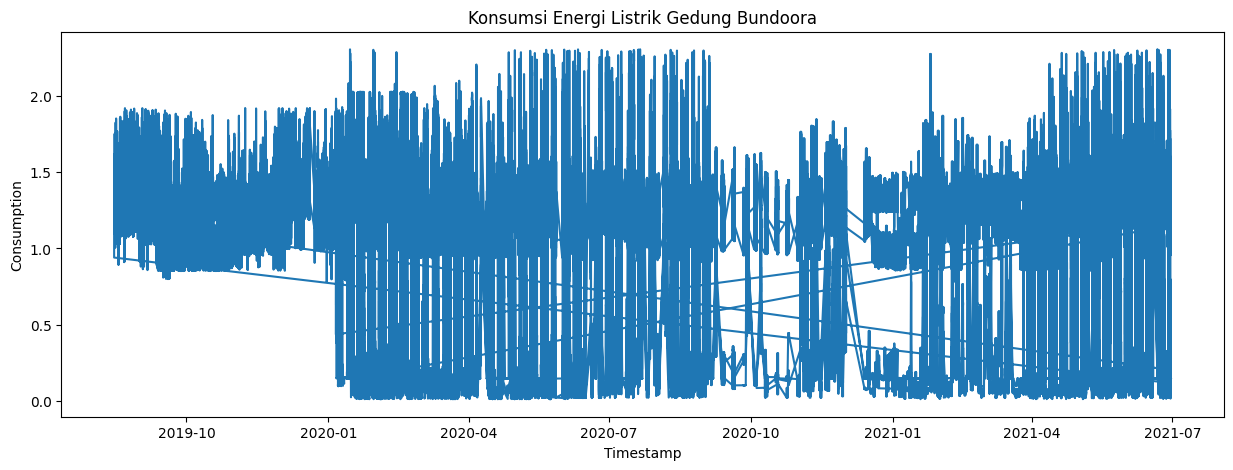

In [30]:
# Visualisasi konsumsi energi listrik

plt.figure(figsize=(15,5))
plt.plot(df['timestamp'], df['consumption'])
plt.xlabel('Timestamp')
plt.ylabel('Consumption')
plt.title('Konsumsi Energi Listrik Gedung Bundoora')
plt.show()

In [31]:
# Feature Selection

features = [
    'current',
    'voltage',
    'power',
    'power_factor',
    'apparent_temperature',
    'air_temperature',
    'dew_point_temperature',
    'relative_humidity',
    'wind_speed',
    'wind_direction'
]

target = 'consumption'

dataset = df[features + [target]]

display(dataset.head())

,current,voltage,power,power_factor,apparent_temperature,air_temperature,dew_point_temperature,relative_humidity,wind_speed,wind_direction,consumption
0,8.34,240.0,1.9015,0.95,21.4,20.7,12.1,58.0,0.0,38.0,0.1585
1,25.44,240.0,17.4019,0.95,21.2,20.6,12.1,58.0,0.0,38.0,1.4502
2,34.31,240.0,15.6456,0.95,21.2,20.6,12.1,58.0,0.0,38.0,1.3038
3,41.70,240.0,9.5081,0.95,20.4,20.5,12.0,58.0,3.6,47.0,0.7923
4,38.49,240.0,17.5524,0.95,20.6,20.3,12.3,60.0,5.4,61.0,1.4627


In [32]:
# Normalisasi data

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(dataset)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=dataset.columns
)

display(scaled_df.head())

,current,voltage,power,power_factor,apparent_temperature,air_temperature,dew_point_temperature,relative_humidity,wind_speed,wind_direction,consumption
0,0.129979,1.0,0.063731,0.0,0.554371,0.482916,0.552632,0.543478,0.000000,0.105850,0.063735
1,0.410261,1.0,0.627222,0.0,0.550107,0.480638,0.552632,0.543478,0.000000,0.105850,0.627230
2,0.555647,1.0,0.563375,0.0,0.550107,0.480638,0.552632,0.543478,0.000000,0.105850,0.563364
3,0.676774,1.0,0.340256,0.0,0.533049,0.478360,0.548872,0.543478,0.064982,0.130919,0.340226
4,0.624160,1.0,0.632693,0.0,0.537313,0.473804,0.560150,0.565217,0.097473,0.169916,0.632683


In [33]:
# Membuat sequence data untuk LSTM

def create_sequences(data, time_steps=24):
    X = []
    y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps, :-1])
        y.append(data[i + time_steps, -1])

    return np.array(X), np.array(y)

In [34]:
# Menentukan time step
# 24 berarti model menggunakan 24 data sebelumnya untuk memprediksi data berikutnya

TIME_STEPS = 24

X, y = create_sequences(scaled_df.values, TIME_STEPS)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (471529, 24, 10)
Shape y: (471529,)


In [35]:
# Split data training dan testing
# Data tidak diacak karena merupakan data time series

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Menyimpan timestamp untuk data target
timestamp_data = df['timestamp'].iloc[TIME_STEPS:].reset_index(drop=True)
timestamp_test = timestamp_data.iloc[split:].reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("Data testing mulai:", timestamp_test.min())
print("Data testing sampai:", timestamp_test.max())

X_train: (377223, 24, 10)
X_test : (94306, 24, 10)
y_train: (377223,)
y_test : (94306,)
Data testing mulai: 2020-01-05 20:25:00
Data testing sampai: 2021-06-30 02:35:00


In [36]:
# Membangun model LSTM

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
# Compile model

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Training model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 92s 9ms/step - loss: 0.0037 - val_loss: 0.0011
Epoch 2/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 87s 9ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 3/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 87s 9ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 4/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 86s 9ms/step - loss: 0.0026 - val_loss: 0.0010
Epoch 5/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 87s 9ms/step - loss: 0.0025 - val_loss: 9.7183e-04
Epoch 6/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 86s 9ms/step - loss: 0.0025 - val_loss: 9.9240e-04
Epoch 7/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 143s 9ms/step - loss: 0.0024 - val_loss: 8.8988e-04
Epoch 8/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 86s 9ms/step - loss: 0.0024 - val_loss: 9.4209e-04
Epoch 9/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 86s 9ms/step - loss: 0.0023 - val_loss: 8.8139e-04
Epoch 10/10
9431/9431 ━━━━━━━━━━━━━━━━━━━━ 86s 9ms/step - loss: 0.0023 - val_loss: 8.5576e-04


In [39]:
# Save model format terbaru

model.save('/content/drive/MyDrive/model_lstm_bundoora.keras')

print("Model berhasil disimpan di Google Drive")

Model berhasil disimpan di Google Drive


In [40]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/model_lstm_bundoora.keras')

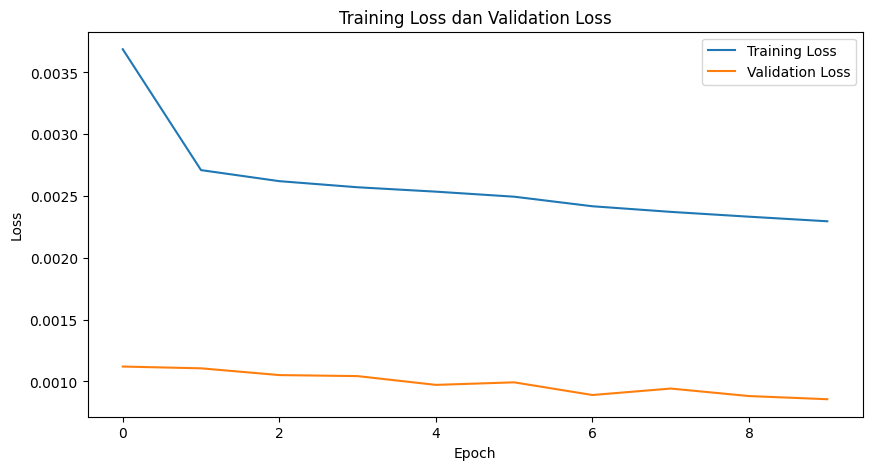

In [41]:
# Visualisasi training loss dan validation loss

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss dan Validation Loss')
plt.legend()
plt.show()

In [42]:
# Prediksi data testing

y_pred = model.predict(X_test)

2948/2948 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


In [43]:
# Mengembalikan hasil prediksi dan data aktual ke skala asli

target_scaler = MinMaxScaler()
target_scaler.fit(dataset[[target]])

y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = target_scaler.inverse_transform(y_pred)

hasil_prediksi = pd.DataFrame({
    'timestamp': timestamp_test,
    'actual_consumption': y_test_actual.flatten(),
    'predicted_consumption': y_pred_actual.flatten()
})

hasil_prediksi['year'] = hasil_prediksi['timestamp'].dt.year

display(hasil_prediksi.head())

,timestamp,actual_consumption,predicted_consumption,year
0,2021-06-16 06:40:00,1.1959,1.251529,2021
1,2021-06-16 06:45:00,1.1945,1.231264,2021
2,2021-06-16 06:50:00,1.3216,1.236272,2021
3,2021-06-16 06:55:00,1.2866,1.282482,2021
4,2021-06-16 07:05:00,1.1913,1.243342,2021


In [44]:
# Evaluasi model pada skala asli

mae = mean_absolute_error(
    hasil_prediksi['actual_consumption'],
    hasil_prediksi['predicted_consumption']
)

rmse = np.sqrt(mean_squared_error(
    hasil_prediksi['actual_consumption'],
    hasil_prediksi['predicted_consumption']
))

mape = np.mean(
    np.abs(
        (hasil_prediksi['actual_consumption'] - hasil_prediksi['predicted_consumption'])
        / hasil_prediksi['actual_consumption']
    )
) * 100

akurasi = 100 - mape

print("MAE   :", mae)
print("RMSE  :", rmse)
print("MAPE  :", mape, "%")
print("Akurasi Model:", akurasi, "%")

MAE   : 0.06189870290396382
RMSE  : 0.1368198553006738
MAPE  : 14.406600414175086 %
Akurasi Model: 85.59339958582491 %


In [46]:
# Prediksi 5 tahun ke depan menggunakan pendekatan recursive forecasting

future_steps = 365 * 5   # 5 tahun, jika data harian
# future_steps = 24 * 365 * 5   # gunakan ini jika data per jam

last_sequence = scaled_df.values[-TIME_STEPS:, :].copy()

future_predictions = []

for i in range(future_steps):
    X_future = last_sequence[:, :-1].reshape(1, TIME_STEPS, len(features))

    pred = model.predict(X_future, verbose=0)

    future_predictions.append(pred[0, 0])

    # Membuat baris baru berdasarkan data terakhir
    new_row = last_sequence[-1, :].copy()

    # Mengganti nilai target consumption dengan hasil prediksi
    new_row[-1] = pred[0, 0]

    # Memasukkan baris baru ke sequence
    last_sequence = np.vstack([last_sequence[1:], new_row])

In [47]:
# Inverse transform hasil prediksi ke skala asli

target_scaler = MinMaxScaler()
target_scaler.fit(dataset[[target]])

future_predictions_actual = target_scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

In [48]:
# Membuat rentang tanggal 5 tahun ke depan

last_date = df['timestamp'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_steps,
    freq='D'
)

future_df = pd.DataFrame({
    'timestamp': future_dates,
    'predicted_consumption': future_predictions_actual.flatten()
})

future_df['year'] = future_df['timestamp'].dt.year

display(future_df.head())
display(future_df.tail())

,timestamp,predicted_consumption,year
0,2021-07-01 02:35:00,0.134587,2021
1,2021-07-02 02:35:00,0.134263,2021
2,2021-07-03 02:35:00,0.133890,2021
3,2021-07-04 02:35:00,0.133810,2021
4,2021-07-05 02:35:00,0.133797,2021


,timestamp,predicted_consumption,year
1820,2026-06-25 02:35:00,0.13374,2026
1821,2026-06-26 02:35:00,0.13374,2026
1822,2026-06-27 02:35:00,0.13374,2026
1823,2026-06-28 02:35:00,0.13374,2026
1824,2026-06-29 02:35:00,0.13374,2026


In [49]:
# Rekap prediksi konsumsi listrik per tahun

prediksi_tahunan = future_df.groupby('year')['predicted_consumption'].sum().reset_index()

prediksi_tahunan.columns = ['Tahun', 'Prediksi Konsumsi Listrik']

display(prediksi_tahunan)

,Tahun,Prediksi Konsumsi Listrik
0,2021,24.610035
1,2022,48.814919
2,2023,48.814919
3,2024,48.948658
4,2025,48.814919
5,2026,24.073111


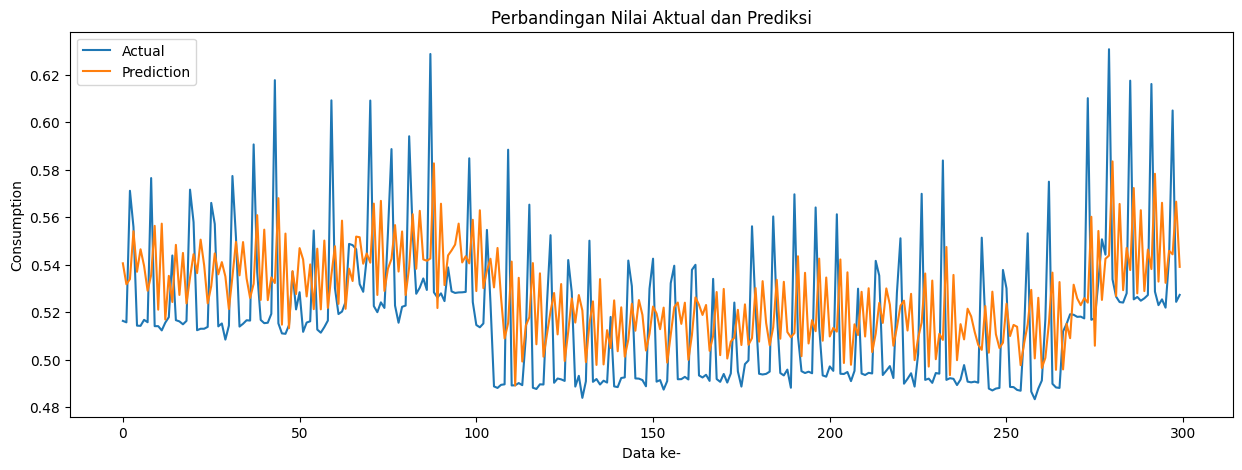

In [50]:
# Visualisasi hasil prediksi

plt.figure(figsize=(15,5))

plt.plot(y_test[:300], label='Actual')
plt.plot(y_pred[:300], label='Prediction')

plt.title('Perbandingan Nilai Aktual dan Prediksi')
plt.xlabel('Data ke-')
plt.ylabel('Consumption')
plt.legend()

plt.show()

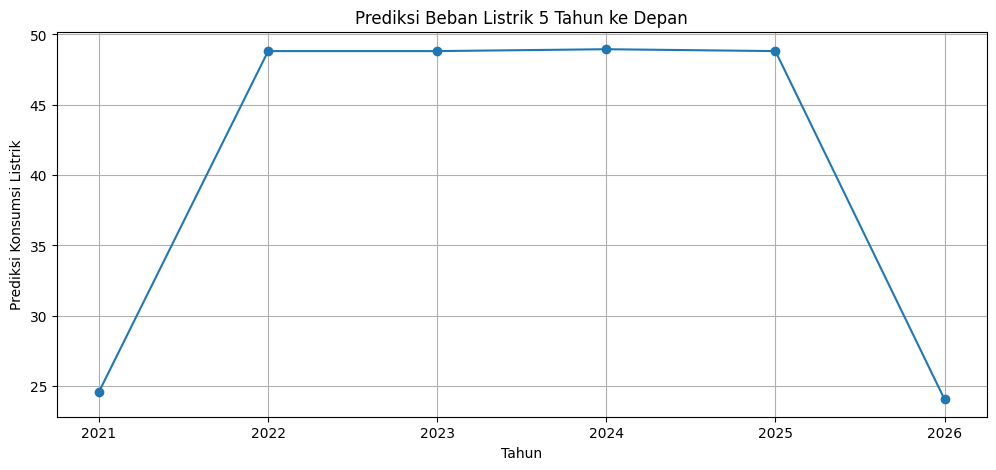

In [51]:
# Visualisasi prediksi 5 tahun ke depan

plt.figure(figsize=(12,5))

plt.plot(
    prediksi_tahunan['Tahun'],
    prediksi_tahunan['Prediksi Konsumsi Listrik'],
    marker='o'
)

plt.title('Prediksi Beban Listrik 5 Tahun ke Depan')
plt.xlabel('Tahun')
plt.ylabel('Prediksi Konsumsi Listrik')
plt.grid(True)
plt.show()

# Kesimpulan sementara

In [52]:

print("Model LSTM telah berhasil dibuat untuk memprediksi beban listrik")
print("pada gedung Bundoora La Trobe University dengan campus_id = 1.")
print("Evaluasi model dilakukan menggunakan MAE dan RMSE.")

Model LSTM telah berhasil dibuat untuk memprediksi beban listrik
pada gedung Bundoora La Trobe University dengan campus_id = 1.
Evaluasi model dilakukan menggunakan MAE dan RMSE.
